In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, scipy

## reformatting spikes

In [2]:
spikes_df = pd.read_parquet('../data/bin/spikes/spikes.parquet')
spikes_df

,subj,sess,hemi,region,neur_id,base_start,base_stop,enc_spikes,base_spikes
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744...","[480.504041, 480.822666, 481.2748535, 481.3912..."
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,...","[484.50519625, 484.55057125, 486.2016015, 486...."
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707...","[488.7439755, 489.63731925]"
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ...","[478.920417, 478.9386045, 479.02932325, 479.03..."
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175...","[480.52132225, 481.14500975, 481.2111035, 481...."
...,...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325...","[479.55532375, 479.90207375, 479.90851125, 481..."
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0...","[478.9684175, 479.19073, 481.5164165, 482.3733..."
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087...","[483.2832905, 484.68175925, 484.84519675, 486...."
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1...","[480.00151025, 486.47719575, 486.615352, 488.3..."


In [45]:
from scipy.ndimage import gaussian_filter1d

def get_rates_by_time(spikes_df, bin_dur):
    
    # ends of encoding & baseline
    enc_stop, base_stop = spikes_df['base_start'].max(), spikes_df['base_stop'][0].max()
    
    # binning
    enc_bin_edges = np.arange(0, enc_stop + bin_dur, bin_dur)
    base_bin_edges = np.arange(enc_stop, base_stop + bin_dur, bin_dur)

    # init
    time_by_rates = np.zeros((len(enc_bin_edges)-1,
                              len(spikes_df)))

    col_names = []

    for id, neur in spikes_df.iterrows():

        col_name = neur['hemi'] + '_' + neur['region'] + '_' + neur['neur_id']
        col_names.append(col_name)

        # get enc rates per bin
        enc_spike_counts, _ = np.histogram(neur['enc_spikes'], bins=enc_bin_edges)
        enc_rates = enc_spike_counts / bin_dur

        # get base rates per bin
        base_spike_counts, _ = np.histogram(neur['base_spikes'], bins=base_bin_edges)
        base_rates = base_spike_counts / bin_dur

        # norm
        base_mean, base_sd = np.mean(base_rates), np.std(base_rates)
        enc_rate_normed = (enc_rates - base_mean)# / base_sd

        # smoothing
        enc_rate_smoothed = gaussian_filter1d(enc_rate_normed, sigma=1)

        # save
        time_by_rates[:, id] = enc_rate_smoothed

    return pd.DataFrame(time_by_rates, columns=col_names)

In [46]:
rates_by_time = get_rates_by_time(spikes_df, bin_dur=.3)
rates_by_time.to_parquet('../data/bin/spikes/time_by_rate.parquet', index=False)
rates_by_time

,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0,-1.180952,-0.666667,-0.038095,-6.540789,2.611795,1.069716,-0.476190,0.156648,1.432067,-0.741973,...,-0.095238,0.0,1.240366,-1.066667,-0.095238,-0.509459,12.934475,-1.447619,-0.780952,0.163560
1,-1.180952,-0.666667,-0.038095,-7.228781,0.476864,-0.079679,-0.476190,0.769368,0.297445,0.050272,...,-0.095238,0.0,-0.894565,-1.066667,-0.095238,-0.839294,8.975032,-1.447619,-0.780952,0.879645
2,-1.180952,-0.666667,-0.038095,-7.959189,-0.480132,-0.856704,-0.476190,1.306489,-0.300502,1.393964,...,-0.095238,0.0,-1.850669,-1.066667,-0.095238,0.013895,4.511655,-1.447619,-0.780506,-0.195043
3,-1.180952,-0.666667,-0.038095,-8.558592,-0.315941,-0.856704,-0.476190,0.948447,0.476969,2.365287,...,-0.095238,0.0,-1.657378,-1.066667,-0.095238,1.714620,1.280276,-1.447619,-0.766180,-1.434364
4,-1.180952,-0.666667,-0.038095,-8.152594,-0.868281,-0.079679,-0.476190,0.948447,2.238639,3.157532,...,-0.095238,0.0,-1.864103,-1.066667,-0.095238,2.134053,0.373535,-1.447619,-0.600982,-1.585235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,-1.180952,0.140351,0.768922,7.878764,-0.509678,0.921190,1.033592,-0.023322,0.655042,-0.952381,...,-0.095238,0.0,0.359083,-0.080125,1.234573,-2.451991,-1.755891,-0.281107,0.026065,0.985350
1593,-1.180952,0.663145,0.141875,10.869629,0.474965,0.473107,1.136952,0.141875,0.282226,-0.952381,...,-0.095238,0.0,-1.521166,-0.871923,0.711333,-2.811040,-1.737481,-0.446304,-0.600982,0.881543
1594,-1.180952,0.139905,-0.023322,7.357259,0.460639,-0.244430,1.033592,0.768922,0.282226,-0.952381,...,-0.095238,0.0,-1.658716,-1.051448,0.084732,-2.661507,-1.800209,-0.102589,-0.766180,1.163869
1595,-1.180952,-0.486696,-0.037649,1.981322,-0.689202,-0.886250,0.345600,1.306489,0.654595,-0.952381,...,-0.095238,0.0,-2.238817,-1.066221,-0.080465,-1.870601,-1.903570,-0.640155,-0.780506,0.522941


## comparing plots to P54CS_R2

plotting all 123 neurons, EVEN THOSE WITH 16s PERIODS OF MISSING DATA


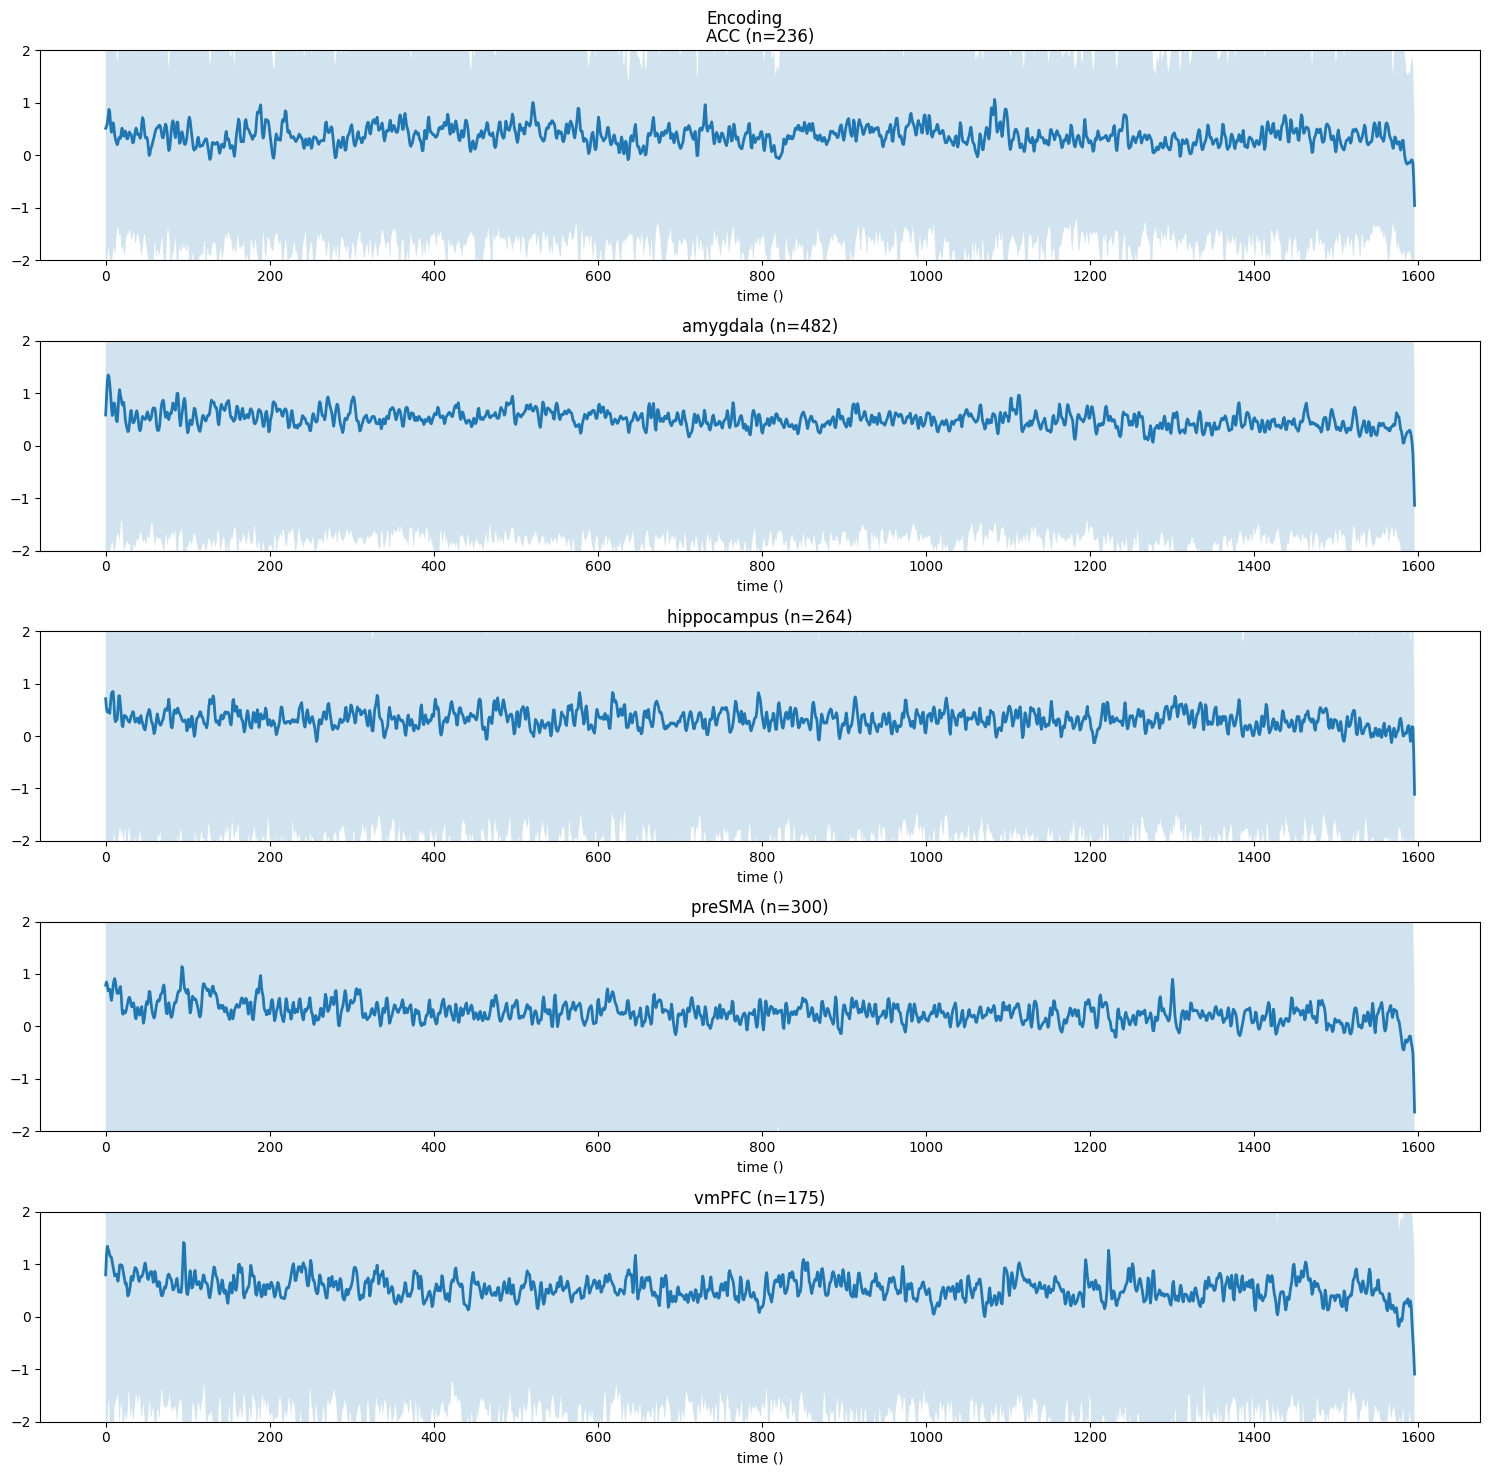

In [65]:
sess = 'P54CS_R1'
sess_cols = [col for col in rates_by_time.columns if sess in col]
sess_df = rates_by_time[sess_cols]
sess_df = rates_by_time

regions = sorted(set([col.split('_')[1] for col in sess_cols]))

print(f'plotting all {len(sess_cols)} neurons, EVEN THOSE WITH 16s PERIODS OF MISSING DATA')

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    region_cols = [col for col in sess_df.columns if region in col]
    sess_reg = sess_df[region_cols].T

    # sns.heatmap(sess_reg, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(sess_reg.values, 99))
    axs[ax].plot(sess_reg.mean(axis=0), linewidth=2, label='region mean')
    axs[ax].fill_between(np.arange(sess_reg.shape[1]),
                         sess_reg.mean(axis=0) - sess_reg.std(axis=0),
                         sess_reg.mean(axis=0) + sess_reg.std(axis=0),
                         alpha=0.2, label='region std')
    axs[ax].set(xlabel='time ()', title = f'{region} (n={sess_reg.shape[0]})', ylim=(-2, 2))
    ax += 1

plt.suptitle('Encoding')

plt.tight_layout()
plt.show()

## checking out annots

In [ ]:
# pickle file
import pickle
with open('../data/bin/spikes/rates_by_time.pickle', 'wb') as f:
    pickle.dump(rates_by_time, f)